# Measuring the Gap Between Mental-Health Need and Treatment Capacity in U.S. Counties, 2018–2023

**Author:** Khushi Desai  
**Course:** Data and the State (DATA 20195 / 30195)

---

## Research question

Across U.S. counties, **where does mental-health need outpace the local capacity of the mental health infrastructure to treat it, and how has that gap moved over recent years?**

To answer this, the notebook builds a **need–capacity mismatch index** at the county level and tracks it longitudinally (2018–2023). *Need* is measured from population mental-health prevalence; *capacity* is measured from the "reach" of local treatment infrastructure, psychiatric facilities, inpatient psychiatric beds, treatment caseloads, and the number of registered psychiatrists. High mismatch marks places where the state's behavioral-health system is least able to meet the burden it faces.

## Background and framing

Mental-health treatment in the United States is delivered through an uneven patchwork of public and private infrastructure, and the **state's capacity to reach the people who need care varies enormously across geography**. A county can have high measured mental-health burden and almost no inpatient psychiatric beds or psychiatrists within reach; another can have ample infrastructure relative to its need. A simple count of treatment facilities, the measure used in the earlier draft of this project, hides this, because it treats a small outpatient office and a 200-bed psychiatric hospital as equivalent.

This notebook therefore reframes *capacity* as **reach**: not how many facilities exist, but how much treatment a place can actually deliver, beds, wards, caseload, and clinicians. Setting that against modeled mental-health prevalence yields a mismatch index that speaks directly to questions of **state capacity and distributive equity** in mental health.

## Data sources

| Source | Measures | Geographic level | Years used | Role |
|---|---|---|---|---|
| **CDC PLACES** | Poor mental health (MHLTH), depression (DEPRESSION) — model-based prevalence | County | 2018–2023 (by data year) | **Need** |
| **U.S. Census ACS (5-yr)** | Population, median income, poverty, unemployment, race/ethnicity | County | rolling 5-yr windows | **Controls** |
| **SAMHSA N-MHSS / N-SUMHSS** | Facility type (wards), inpatient psychiatric beds, client counts (caseload) | Facility → county | available survey years | **Capacity** |
| **HRSA AHRF** | Registered psychiatrists, hospital counts | County (multi-year file) | 2018–2023 | **Capacity** |

*Comparability caveats for each source are documented in Part 6 (Limitations) — they are central to interpreting the results, not an afterthought.*

---

## Part 1: Setup

In [33]:
# Run once if these are not already installed:
!pip install pandas numpy geopandas matplotlib seaborn requests shapely pyproj statsmodels scipy pyreadr libpysal esda openpyxl

In [34]:
import os
import re
import glob
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from scipy import stats
import pyreadr  # SAMHSA .rdata public-use files
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

In [35]:
# Configuration 
NEED_SOURCE = "PLACES"        # "PLACES" (2018–2023) or "CHR" (back to ~2011, methodology break)
PRIMARY_NEED = "MHLTH"        # "MHLTH" (poor mental health) or "DEPRESSION"
DATA_YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
DATA_DIR = "data"

CENSUS_API_KEY = os.environ.get("3069d8192cd0cd67640acf273fd2f19e4695023f")  # don't hard-code; set in your environment

os.makedirs(DATA_DIR, exist_ok=True)


In [36]:
########## Helper functions ##########

def fips5(series):
    """Coerce a county identifier to a clean 5-digit FIPS string."""
    return series.astype(str).str.extract(r"(\d+)")[0].str.zfill(5)

def zscore_within(df, value_col, group_col="year"):
    """Standardize a column within each group (e.g., within each year)."""
    g = df.groupby(group_col)[value_col]
    return (df[value_col] - g.transform("mean")) / g.transform("std")

## Part 2: Data acquisition and cleaning

The following subsections load one raw source, clean it, and reduce it to a **tidy county–year frame** keyed on `county_fips` and `year`. These are merged into a single panel in Part 3.

### 2.1 CDC PLACES: Mental Health Need

This section cleans the CDC PLACES county-level data and constructs the project’s core measure of mental-health need. I use crude prevalence estimates for poor mental health and depression, then convert poor mental-health prevalence into an estimated count of residents experiencing poor mental health in each county.


In [67]:
places_files = [
    ("data/places_county_2020.csv", 2020),
    ("data/places_county_2021.csv", 2021),
    ("data/places_county_2022.csv", 2022),
    ("data/places_county_2023.csv", 2023),
    ("data/places_county_2024.csv", 2024),
    ("data/places_county_2025.csv", 2025)
]

places_list = []

for file, year in places_files:
    df = pd.read_csv(file)

    keep_cols = [
        "StateAbbr",
        "CountyName",
        "CountyFIPS",
        "TotalPopulation",
        "MHLTH_CrudePrev"
    ]

    if "DEPRESSION_CrudePrev" in df.columns:
        keep_cols.append("DEPRESSION_CrudePrev")

    df = df[keep_cols].copy()

    df = df.rename(columns={
        "StateAbbr": "state",
        "CountyName": "county_name",
        "CountyFIPS": "county_fips",
        "TotalPopulation": "population",
        "MHLTH_CrudePrev": "poor_mental_health",
        "DEPRESSION_CrudePrev": "depression"
    })

    if "depression" not in df.columns:
        df["depression"] = np.nan

    df["year"] = year

    df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)

    df["population"] = (
        df["population"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    df["poor_mental_health"] = pd.to_numeric(df["poor_mental_health"], errors="coerce")
    df["depression"] = pd.to_numeric(df["depression"], errors="coerce")

    df["estimated_need"] = df["population"] * df["poor_mental_health"] / 100

    places_list.append(df)

places_panel = pd.concat(places_list, ignore_index=True)

places_panel.head()

,state,county_name,county_fips,population,poor_mental_health,depression,year,estimated_need
0,AL,Autauga,01001,55601.0,15.4,NaN,2020,8562.554
1,AL,Baldwin,01003,218022.0,13.8,NaN,2020,30087.036
2,AL,Barbour,01005,24881.0,18.2,NaN,2020,4528.342
3,AL,Bibb,01007,22400.0,16.7,NaN,2020,3740.800
4,AL,Blount,01009,57840.0,16.3,NaN,2020,9427.920


Several patterns emerge from the county-year panel. Across 2020–2025, the average county poor mental-health prevalence is approximately 15.7%, though there is substantial geographic variation, ranging from 8.2% to 26.2%. The average estimated county mental-health burden is roughly 15,700 residents, but this distribution is highly skewed by population size: large metropolitan counties contain substantially larger absolute populations experiencing poor mental health than smaller rural counties.

This distinction between prevalence and estimated burden is important for the later construction of treatment-capacity mismatch measures. Some counties exhibit high prevalence rates despite relatively small populations, while large urban counties may exhibit moderate prevalence but extremely large absolute treatment demand.

### 2.2 ACS 5-Year Estimates: County Demographic Controls

To contextualize mental-health burden and psychiatric treatment capacity, I use county-level ACS 5-year estimates as demographic and socioeconomic controls. These variables provide information on county poverty, income, unemployment, and broader socioeconomic conditions that may shape both mental-health outcomes and access to psychiatric infrastructure.

In [78]:
acs_panel = pd.read_csv("data/acs_county_panel_2020_2024.csv")

# Standardize county FIPS
acs_panel["county_fips"] = (
    acs_panel["county_fips"]
    .astype(str)
    .str.zfill(5)
)

acs_panel.head()

,county_fips,county_name,year,total_pop,median_income,poverty_rate,unemployment_rate,pct_nh_white,pct_nh_black,pct_hispanic
0,01001,"Autauga County, Alabama",2020,55639,57982,15.086540,2.907252,73.976887,19.498913,2.877478
1,01003,"Baldwin County, Alabama",2020,218289,61756,9.042599,3.917506,82.896985,8.716426,4.556803
2,01005,"Barbour County, Alabama",2020,25026,34990,25.221769,6.936725,45.280908,47.506593,4.435387
3,01007,"Bibb County, Alabama",2020,22374,51721,16.782873,7.435897,74.416734,22.217753,2.681684
4,01009,"Blount County, Alabama",2020,57755,48922,13.586702,5.201544,86.685135,1.334949,9.284045


### 2.3 Psychiatric Infrastructure Data: SAMHSA and AHRF

To measure psychiatric treatment capacity, I explored both the SAMHSA National Mental Health Services Survey (N-MHSS/N-SUMHSS) facility files and the Area Health Resource File (AHRF).

The SAMHSA facility files contain detailed information on inpatient psychiatric services, psychiatric beds, hospital settings, and inpatient treatment utilization. However, the public-use versions of these files do not consistently expose county-level geographic identifiers, limiting direct county-level aggregation.

To complement these infrastructure measures, I use AHRF psychiatrist supply data, including psychiatrist rates per population. Together, these datasets provide a partial but informative view of psychiatric treatment capacity across places and over time.

In [79]:
# -------------------------------
# Load AHRF psychiatrist supply data
# -------------------------------

ahrf = pd.read_excel("data/AHRF_2022.xlsx")

ahrf.head()

,State/Territory,"M.D., Psychiatry (County Level File)","Population, All (County Level File)","Rate (per 100,000 population)",Source
0,Alabama,334.0,5074296.0,6.58,AMA Physician Professional Data 2022; Census C...
1,Alaska,74.0,733583.0,10.09,AMA Physician Professional Data 2022; Census C...
2,Arizona,684.0,7359197.0,9.29,AMA Physician Professional Data 2022; Census C...
3,Arkansas,267.0,3045637.0,8.77,AMA Physician Professional Data 2022; Census C...
4,California,6168.0,39029342.0,15.80,AMA Physician Professional Data 2022; Census C...


In [81]:
# -------------------------------
# Clean multiple AHRF psychiatrist files
# -------------------------------

ahrf_files = [
    ("data/AHRF_2020.xlsx", 2020),
    ("data/AHRF_2021.xlsx", 2021),
    ("data/AHRF_2022.xlsx", 2022),
    ("data/AHRF_2023.xlsx", 2023),
    ("data/AHRF_2024.xlsx", 2024)
]

ahrf_list = []

for file, year in ahrf_files:
    df = pd.read_excel(file)

    df = df[[
        "State/Territory",
        "M.D., Psychiatry (County Level File)",
        "Population, All (County Level File)",
        "Rate (per 100,000 population)"
    ]].copy()

    df = df.rename(columns={
        "State/Territory": "state",
        "M.D., Psychiatry (County Level File)": "psychiatrists",
        "Population, All (County Level File)": "population",
        "Rate (per 100,000 population)": "psychiatrists_per_100k"
    })

    df["year"] = year

    for col in ["psychiatrists", "population", "psychiatrists_per_100k"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    ahrf_list.append(df)

ahrf_panel = pd.concat(ahrf_list, ignore_index=True)

ahrf_panel.head()

KeyError: "None of [Index(['State/Territory', 'M.D., Psychiatry (County Level File)',\n       'Population, All (County Level File)', 'Rate (per 100,000 population)'],\n      dtype='str')] are in the [columns]"

In [84]:
# -------------------------------
# Clean multiple AHRF psychiatrist files
# -------------------------------

ahrf_files = [
    ("data/AHRF_2020.xlsx", 2020),
    ("data/AHRF_2021.xlsx", 2021),
    ("data/AHRF_2022.xlsx", 2022),
    ("data/AHRF_2023.xlsx", 2023),
    ("data/AHRF_2024.xlsx", 2024)
]

ahrf_list = []

for file, year in ahrf_files:
    df = pd.read_excel(file)

    df = df[[
        "State/Territory",
        "M.D., Psychiatry (County Level File)",
        "Population, All (County Level File)",
        "Rate (per 100,000 population)"
    ]].copy()

    df = df.rename(columns={
        "State/Territory": "state",
        "M.D., Psychiatry (County Level File)": "psychiatrists",
        "Population, All (County Level File)": "population",
        "Rate (per 100,000 population)": "psychiatrists_per_100k"
    })

    df["year"] = year

    for col in ["psychiatrists", "population", "psychiatrists_per_100k"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    ahrf_list.append(df)

ahrf_panel = pd.concat(ahrf_list, ignore_index=True)

ahrf_panel.head()

,state,psychiatrists,population,psychiatrists_per_100k,year
0,Alabama,332.0,4921532.0,6.75,2020
1,Alaska,73.0,740504.0,9.86,2020
2,Arizona,660.0,7421401.0,8.89,2020
3,Arkansas,255.0,3030522.0,8.41,2020
4,California,6043.0,39368078.0,15.35,2020


In [85]:
ahrf_panel.to_csv("data/ahrf_psychiatrist_supply_panel.csv", index=False)

The cleaned AHRF panel provides longitudinal state-level psychiatrist workforce capacity from 2020–2024. The dataset includes both total psychiatrists and psychiatrists per 100,000 residents. Although these measures are available only at the state level in the public-use files used here, they provide an important measure of psychiatric workforce availability that complements the county-level mental-health burden panel.

### 2.4 SAMHSA Psychiatric Infrastructure Data

I use SAMHSA descriptively rather than as part of the merged county panel. The public-use files contain useful infrastructure variables, including inpatient psychiatric services, psychiatric beds, inpatient clients, hospital status, and state location. However, they do not provide reliable county-level identifiers for direct county merging. I therefore use SAMHSA to characterize psychiatric infrastructure at the facility and state level.### 2D — HRSA AHRF (capacity: psychiatrists, hospitals)
*To build.* Read the AHRF county file (internally multi-year), extract psychiatrist counts and hospital counts for each year in `DATA_YEARS`. Output: `ahrf_panel[county_fips, year, psychiatrists, hospitals]`.

In [91]:

samhsa_files = [
    ("data/samhsa_2019.csv", 2019),
    ("data/samhsa_2021.csv", 2021),
    ("data/samhsa_2023.csv", 2023)
]

samhsa_list = []

capacity_vars = [
    "LOCATIONSTATE",
    "FACILITYTYPE",
    "HOSPITAL",
    "IPSERV",
    "IPBEDS",
    "IPTOTAL"
]

for file, year in samhsa_files:
    df = pd.read_csv(file)

    keep_cols = [col for col in capacity_vars if col in df.columns]
    df = df[keep_cols].copy()

    df = df.rename(columns={
        "LOCATIONSTATE": "state",
        "FACILITYTYPE": "facility_type",
        "HOSPITAL": "hospital",
        "IPSERV": "inpatient_psych_service",
        "IPBEDS": "inpatient_psych_beds",
        "IPTOTAL": "inpatient_clients"
    })

    df["year"] = year

    for col in ["hospital", "inpatient_psych_service", "inpatient_psych_beds", "inpatient_clients"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            df[col] = np.nan

    samhsa_list.append(df)

samhsa_capacity = pd.concat(samhsa_list, ignore_index=True)

samhsa_capacity.head()

,facility_type,year,hospital,inpatient_psych_service,inpatient_psych_beds,inpatient_clients,state
0,7.0,2019,NaN,NaN,NaN,NaN,NaN
1,7.0,2019,NaN,NaN,NaN,NaN,NaN
2,9.0,2019,NaN,NaN,NaN,NaN,NaN
3,10.0,2019,NaN,NaN,NaN,NaN,NaN
4,7.0,2019,NaN,NaN,NaN,NaN,NaN


In [92]:
# State-year infrastructure summary

samhsa_state_panel = (
    samhsa_capacity
    .groupby(["state", "year"], as_index=False)
    .agg(
        n_facilities=("facility_type", "count"),
        n_hospitals=("hospital", lambda x: (x == 1).sum()),
        n_inpatient_psych_facilities=("inpatient_psych_service", lambda x: (x == 1).sum()),
        total_inpatient_psych_beds=("inpatient_psych_beds", "sum"),
        total_inpatient_clients=("inpatient_clients", "sum")
    )
)

samhsa_state_panel.head()

,state,year,n_facilities,n_hospitals,n_inpatient_psych_facilities,total_inpatient_psych_beds,total_inpatient_clients
0,AK,2021,73,16,4,107.0,85.0
1,AK,2023,81,12,5,150.0,100.0
2,AL,2021,124,27,27,873.0,1021.0
3,AL,2023,130,13,27,1170.0,1291.0
4,AR,2021,154,15,19,738.0,604.0


The SAMHSA files are not merged to the county panel, but they are aggregated to the state-year level to describe psychiatric infrastructure over time. This preserves useful information on facilities, hospitals, inpatient psychiatric facilities, beds, and clients without making unsupported county-level geographic claims.

## Part 3 — Build the Analytic County-Year Panel

This section merges the cleaned CDC PLACES mental-health burden panel, ACS socioeconomic controls, AHRF psychiatrist workforce capacity data, and SAMHSA state-level infrastructure summaries. The goal is to create one analysis-ready county-year panel.

In [94]:
analysis_df = places_panel.merge(
    acs_panel,
    on=["county_fips", "year"],
    how="left",
    suffixes=("", "_acs")
)

analysis_df.head()

,state,county_name,county_fips,population,poor_mental_health,depression,year,estimated_need,county_name_acs,total_pop,median_income,poverty_rate,unemployment_rate,pct_nh_white,pct_nh_black,pct_hispanic
0,AL,Autauga,01001,55601.0,15.4,NaN,2020,8562.554,"Autauga County, Alabama",55639.0,57982.0,15.086540,2.907252,73.976887,19.498913,2.877478
1,AL,Baldwin,01003,218022.0,13.8,NaN,2020,30087.036,"Baldwin County, Alabama",218289.0,61756.0,9.042599,3.917506,82.896985,8.716426,4.556803
2,AL,Barbour,01005,24881.0,18.2,NaN,2020,4528.342,"Barbour County, Alabama",25026.0,34990.0,25.221769,6.936725,45.280908,47.506593,4.435387
3,AL,Bibb,01007,22400.0,16.7,NaN,2020,3740.800,"Bibb County, Alabama",22374.0,51721.0,16.782873,7.435897,74.416734,22.217753,2.681684
4,AL,Blount,01009,57840.0,16.3,NaN,2020,9427.920,"Blount County, Alabama",57755.0,48922.0,13.586702,5.201544,86.685135,1.334949,9.284045


The PLACES and ACS panels are merged by county FIPS and year. Because the ACS panel currently covers 2020–2024, PLACES observations from 2025 will not have ACS controls unless a later ACS file is added.

In [96]:
# -------------------------------
# Add full state names
# -------------------------------

state_map = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut",
    "DE": "Delaware", "DC": "District of Columbia", "FL": "Florida",
    "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho", "IL": "Illinois",
    "IN": "Indiana", "IA": "Iowa", "KS": "Kansas", "KY": "Kentucky",
    "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota",
    "MS": "Mississippi", "MO": "Missouri", "MT": "Montana",
    "NE": "Nebraska", "NV": "Nevada", "NH": "New Hampshire",
    "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio",
    "OK": "Oklahoma", "OR": "Oregon", "PA": "Pennsylvania",
    "RI": "Rhode Island", "SC": "South Carolina", "SD": "South Dakota",
    "TN": "Tennessee", "TX": "Texas", "UT": "Utah", "VT": "Vermont",
    "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming"
}

analysis_df["state_full"] = analysis_df["state"].map(state_map)

## Part 4 — Exploratory Analysis

To summarize the relationship between mental-health burden and treatment capacity, I construct a simple mismatch index. The index increases when counties exhibit higher estimated mental-health need, higher poverty, and lower psychiatrist workforce capacity.

In [102]:
analysis_df["need_z"] = (
    analysis_df["estimated_need"] -
    analysis_df["estimated_need"].mean()
) / analysis_df["estimated_need"].std()

analysis_df["poverty_z"] = (
    analysis_df["poverty_rate"] -
    analysis_df["poverty_rate"].mean()
) / analysis_df["poverty_rate"].std()

analysis_df["psy_supply_z"] = (
    analysis_df["psychiatrists_per_100k"] -
    analysis_df["psychiatrists_per_100k"].mean()
) / analysis_df["psychiatrists_per_100k"].std()

analysis_df["mismatch_index"] = (
    analysis_df["need_z"] +
    analysis_df["poverty_z"] -
    analysis_df["psy_supply_z"]
)

analysis_df[[
    "county_name",
    "year",
    "mismatch_index"
]].head()

,county_name,year,mismatch_index
0,Autauga,2020,1.000371
1,Baldwin,2020,0.391500
2,Barbour,2020,2.682193
3,Bibb,2020,1.196394
4,Blount,2020,0.757022


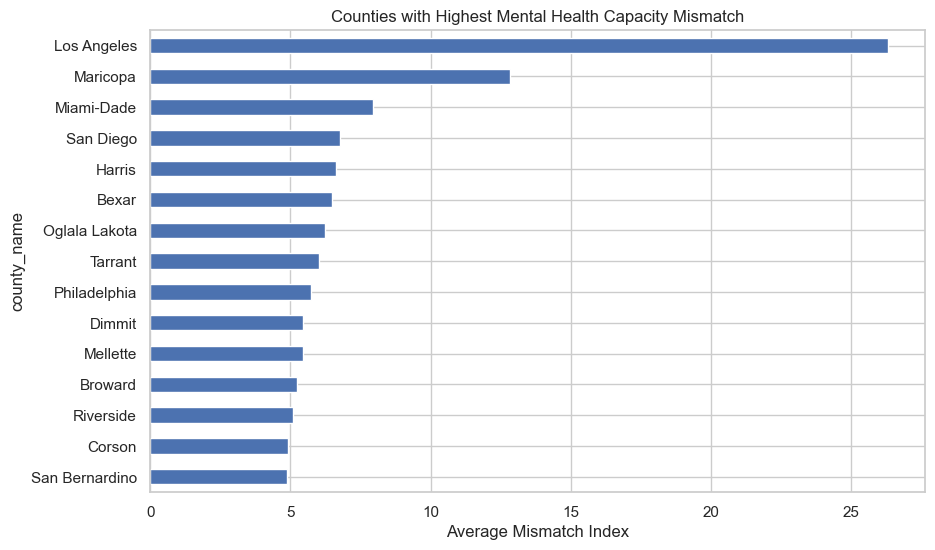

In [106]:
top_mismatch = (
    analysis_df
    .groupby("county_name")["mismatch_index"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

top_mismatch.sort_values().plot(
    kind="barh"
)

plt.title("Counties with Highest Mental Health Capacity Mismatch")
plt.xlabel("Average Mismatch Index")

plt.show()

In [107]:
analysis_df["mismatch_index"].describe()

count    12464.000000
mean        -0.008523
std          1.649798
min         -9.206509
25%         -0.877315
50%         -0.053093
75%          0.820333
max         28.088624
Name: mismatch_index, dtype: float64

The counties with the highest mismatch values include both large urban counties and a smaller number of highly underserved rural counties. Large metropolitan counties tend to exhibit extremely high estimated mental-health need due to population size, while some rural counties appear because of high poverty rates combined with relatively limited psychiatric workforce capacity.

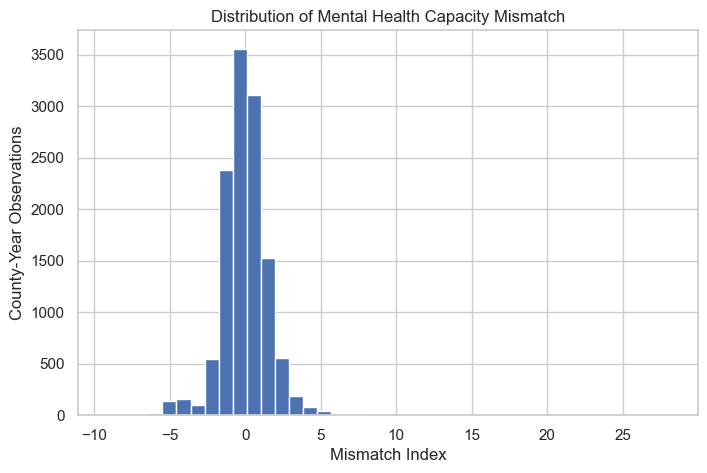

In [108]:
plt.figure(figsize=(8,5))

analysis_df["mismatch_index"].hist(bins=40)

plt.title("Distribution of Mental Health Capacity Mismatch")
plt.xlabel("Mismatch Index")
plt.ylabel("County-Year Observations")

plt.show()

## Part 5 — Psychiatrist Workforce Capacity and Mental Health Burden

To better understand the relationship between treatment capacity and mental-health burden, I visualize the relationship between psychiatrist workforce availability and poor mental-health prevalence across county-years.

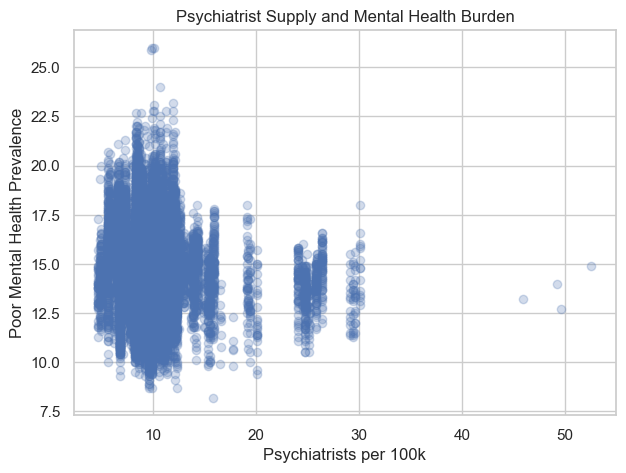

In [109]:
plt.figure(figsize=(7,5))

plt.scatter(
    analysis_df["psychiatrists_per_100k"],
    analysis_df["poor_mental_health"],
    alpha=0.25
)

plt.xlabel("Psychiatrists per 100k")
plt.ylabel("Poor Mental Health Prevalence")

plt.title("Psychiatrist Supply and Mental Health Burden")

plt.show()

The scatterplot does not show a strong linear relationship between psychiatrist workforce supply and poor mental-health prevalence. Counties with similar levels of psychiatrist availability can still exhibit very different mental-health burdens, suggesting that workforce capacity alone does not fully explain geographic variation in mental-health outcomes.

The vertical clustering visible in the plot reflects the fact that psychiatrist workforce capacity is measured at the state-year level using AHRF data, while mental-health burden is measured at the county-year level using CDC PLACES.

In [110]:
# -------------------------------
# Urban vs rural classification
# -------------------------------

analysis_df["county_type"] = np.where(
    analysis_df["population"] >= 100000,
    "Urban",
    "Rural"
)

analysis_df["county_type"].value_counts()

county_type
Rural    15217
Urban     3640
Name: count, dtype: int64

<Figure size 800x600 with 0 Axes>

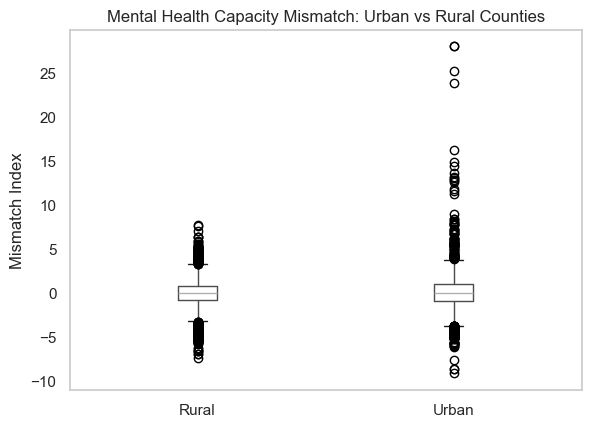

In [111]:
plt.figure(figsize=(8,6))

analysis_df.boxplot(
    column="mismatch_index",
    by="county_type",
    grid=False
)

plt.title("Mental Health Capacity Mismatch: Urban vs Rural Counties")
plt.suptitle("")

plt.xlabel("")
plt.ylabel("Mismatch Index")

plt.show()

Urban counties exhibit substantially greater dispersion in mismatch values than rural counties. While many rural counties cluster near the center of the distribution, several urban counties appear as extremely high-mismatch outliers, likely reflecting the combination of very large populations, elevated estimated mental-health need, and workforce constraints relative to demand.

At the same time, the presence of both positive and negative outliers across county types suggests that mental-health infrastructure inequality is not purely an urban-rural divide. Instead, mismatch appears to emerge from the interaction between population scale, socioeconomic vulnerability, and psychiatric workforce capacity.

In [115]:
# -------------------------------
# Make SAMHSA state names mergeable
# -------------------------------

state_map = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut",
    "DE": "Delaware", "DC": "District of Columbia", "FL": "Florida",
    "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho", "IL": "Illinois",
    "IN": "Indiana", "IA": "Iowa", "KS": "Kansas", "KY": "Kentucky",
    "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota",
    "MS": "Mississippi", "MO": "Missouri", "MT": "Montana",
    "NE": "Nebraska", "NV": "Nevada", "NH": "New Hampshire",
    "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio",
    "OK": "Oklahoma", "OR": "Oregon", "PA": "Pennsylvania",
    "RI": "Rhode Island", "SC": "South Carolina", "SD": "South Dakota",
    "TN": "Tennessee", "TX": "Texas", "UT": "Utah", "VT": "Vermont",
    "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming"
}

samhsa_state_panel["state_full"] = samhsa_state_panel["state"].map(state_map)

state_capacity = samhsa_state_panel.merge(
    ahrf_panel[["state", "year", "population"]],
    left_on=["state_full", "year"],
    right_on=["state", "year"],
    how="left",
    suffixes=("", "_ahrf")
)

state_capacity["beds_per_100k"] = (
    state_capacity["total_inpatient_psych_beds"] /
    state_capacity["population"]
) * 100000

state_capacity.head()

,state,year,n_facilities,n_hospitals,n_inpatient_psych_facilities,total_inpatient_psych_beds,total_inpatient_clients,state_full,state_ahrf,population,beds_per_100k
0,AK,2021,73,16,4,107.0,85.0,Alaska,Alaska,732673.0,14.604059
1,AK,2023,81,12,5,150.0,100.0,Alaska,Alaska,733406.0,20.452519
2,AL,2021,124,27,27,873.0,1021.0,Alabama,Alabama,5039877.0,17.321851
3,AL,2023,130,13,27,1170.0,1291.0,Alabama,Alabama,5108468.0,22.903148
4,AR,2021,154,15,19,738.0,604.0,Arkansas,Arkansas,3025891.0,24.389510


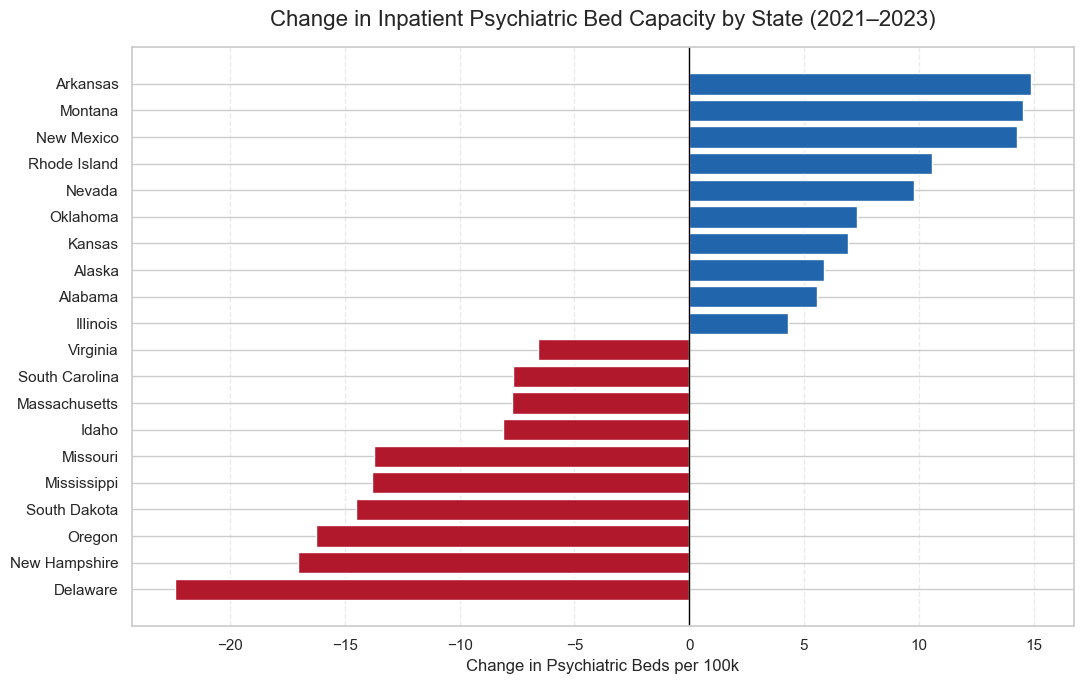

In [118]:
# -------------------------------
# Colorful diverging SAMHSA plot
# -------------------------------

plot_df = change_plot.reset_index()
plot_df.columns = ["state", "change"]

colors = [
    "#2166ac" if x > 0 else "#b2182b"
    for x in plot_df["change"]
]

plt.figure(figsize=(11,7))

plt.barh(
    plot_df["state"],
    plot_df["change"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Change in Inpatient Psychiatric Bed Capacity by State (2021–2023)",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "Change in Psychiatric Beds per 100k",
    fontsize=12
)

plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

State-level psychiatric bed capacity changed substantially between 2021 and 2023, with some states experiencing sizable increases while others saw notable declines. States such as Arkansas, Montana, and New Mexico experienced some of the largest increases in inpatient psychiatric bed capacity per capita, while Delaware, New Hampshire, and Oregon experienced some of the largest declines.

The figure highlights that psychiatric treatment infrastructure is not static. Capacity changes meaningfully across states and over time, reinforcing the importance of using longitudinal rather than purely cross-sectional measures of mental-health infrastructure.

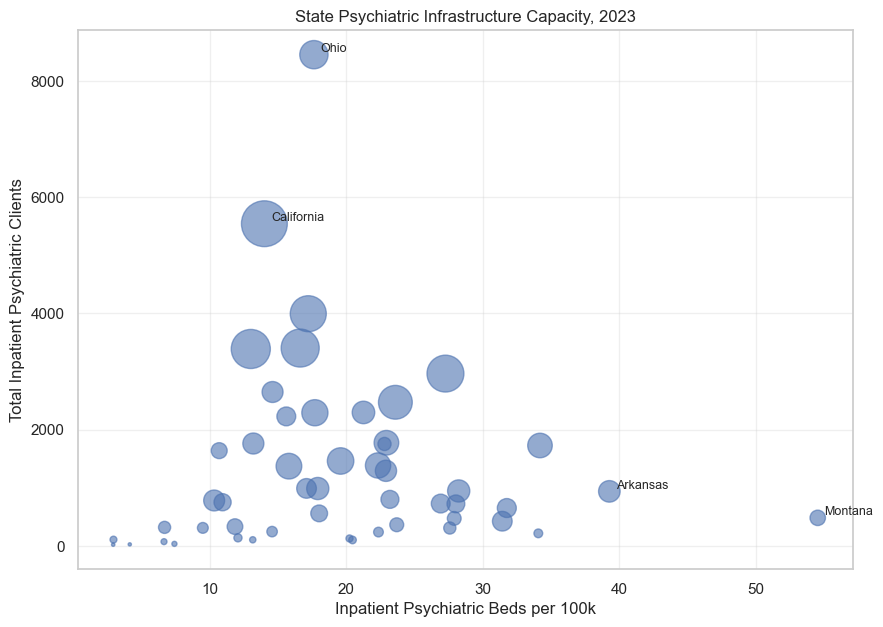

In [120]:
# -------------------------------
# State-level capacity comparison, 2023
# -------------------------------

state_viz = state_capacity[state_capacity["year"] == 2023].copy()

state_viz = state_viz.dropna(subset=[
    "beds_per_100k",
    "total_inpatient_clients",
    "total_inpatient_psych_beds"
])

plt.figure(figsize=(10,7))

plt.scatter(
    state_viz["beds_per_100k"],
    state_viz["total_inpatient_clients"],
    s=state_viz["total_inpatient_psych_beds"] / 5,
    alpha=0.6
)

plt.xlabel("Inpatient Psychiatric Beds per 100k")
plt.ylabel("Total Inpatient Psychiatric Clients")
plt.title("State Psychiatric Infrastructure Capacity, 2023")

# Label a few notable states
# Label extreme states only

label_states = state_viz[
    (state_viz["beds_per_100k"] > 35) |
    (state_viz["total_inpatient_clients"] > 5000)
]

for _, row in label_states.iterrows():
    plt.text(
        row["beds_per_100k"] + 0.5,
        row["total_inpatient_clients"] + 50,
        row["state_full"],
        fontsize=9
    )
    
plt.grid(alpha=0.3)
plt.show()

States exhibit substantial variation in psychiatric infrastructure capacity. Some states maintain relatively high inpatient psychiatric bed availability per capita, while others operate with substantially lower infrastructure levels. The bubble sizes further show that states with similar bed availability may still differ substantially in overall inpatient treatment volume, suggesting that psychiatric infrastructure capacity is shaped both by population scale and by broader institutional differences in mental-health systems.

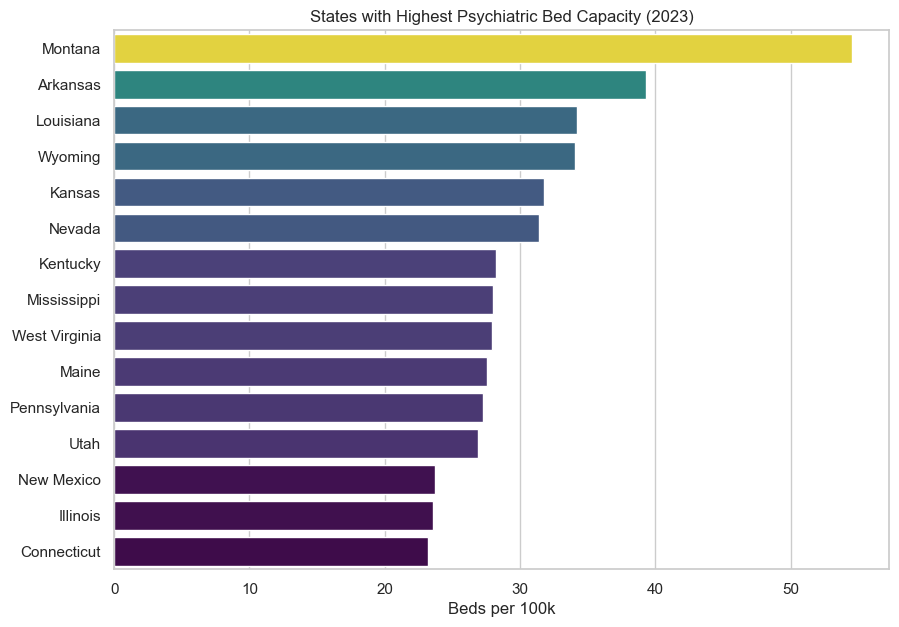

In [123]:
plot_df = (
    state_capacity[state_capacity["year"] == 2023]
    .sort_values("beds_per_100k", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_df,
    y="state_full",
    x="beds_per_100k",
    hue="beds_per_100k",
    palette="viridis",
    dodge=False
)

plt.title("States with Highest Psychiatric Bed Capacity (2023)")
plt.xlabel("Beds per 100k")
plt.ylabel("")

plt.legend([], [], frameon=False)

plt.show()

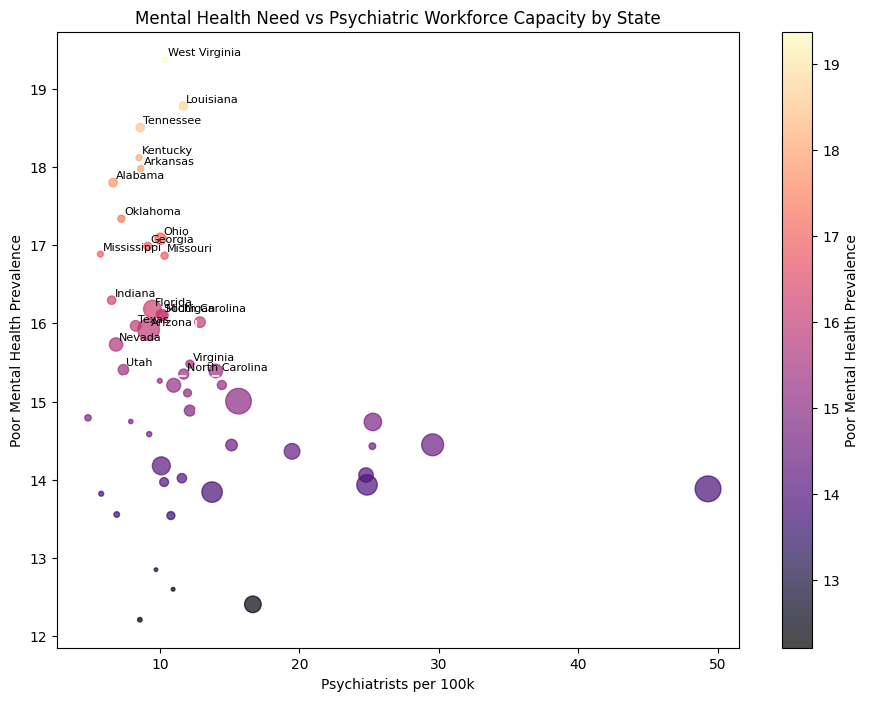

In [137]:
# -------------------------------
# State-level need vs capacity
# -------------------------------

state_analysis = (
    analysis_df.groupby("state_full")
    .agg({
        "poor_mental_health": "mean",
        "psychiatrists_per_100k": "mean",
        "population": "mean"
    })
    .reset_index()
)

plt.figure(figsize=(11,8))

scatter = plt.scatter(
    state_analysis["psychiatrists_per_100k"],
    state_analysis["poor_mental_health"],
    s=state_analysis["population"] / 2000,
    c=state_analysis["poor_mental_health"],
    cmap="magma",
    alpha=0.7
)

# National averages
x_mean = state_analysis["psychiatrists_per_100k"].mean()
y_mean = state_analysis["poor_mental_health"].mean()

plt.axvline(x_mean, linestyle="--", color="white", alpha=0.8)
plt.axhline(y_mean, linestyle="--", color="white", alpha=0.8)

# Label high-need low-capacity states
label_df = state_analysis[
    (state_analysis["poor_mental_health"] > y_mean) &
    (state_analysis["psychiatrists_per_100k"] < x_mean)
]

for _, row in label_df.iterrows():
    plt.text(
        row["psychiatrists_per_100k"] + 0.2,
        row["poor_mental_health"] + 0.05,
        row["state_full"],
        fontsize=8
    )

plt.colorbar(scatter, label="Poor Mental Health Prevalence")

plt.xlabel("Psychiatrists per 100k")
plt.ylabel("Poor Mental Health Prevalence")

plt.title(
    "Mental Health Need vs Psychiatric Workforce Capacity by State"
)

plt.show()

This visualization (average of all years) highlights substantial geographic inequality in mental-health burden relative to psychiatric workforce capacity across U.S. states. States in the upper-left quadrant exhibit particularly concerning combinations of high poor mental-health prevalence and relatively low psychiatrist availability. Several Southern and Appalachian states — including West Virginia, Louisiana, Kentucky, Arkansas, and Tennessee — cluster in this region, suggesting that mental-health burden may be especially difficult to address where psychiatric workforce capacity is comparatively limited.

In contrast, states located toward the lower-right quadrant generally exhibit lower mental-health burden alongside substantially higher psychiatrist availability. These states appear to maintain stronger psychiatric workforce capacity relative to estimated need. The figure therefore suggests that psychiatrist availability is unevenly distributed across the United States and does not align neatly with geographic patterns of mental-health burden.

Bubble size further emphasizes the role of population scale. Large-population states can still exhibit substantial workforce pressure even when psychiatrist availability per capita appears moderate. Overall, the visualization reinforces the central argument of the project: mental-health access should be understood relationally as the balance between population need and treatment capacity, rather than through raw provider counts alone.

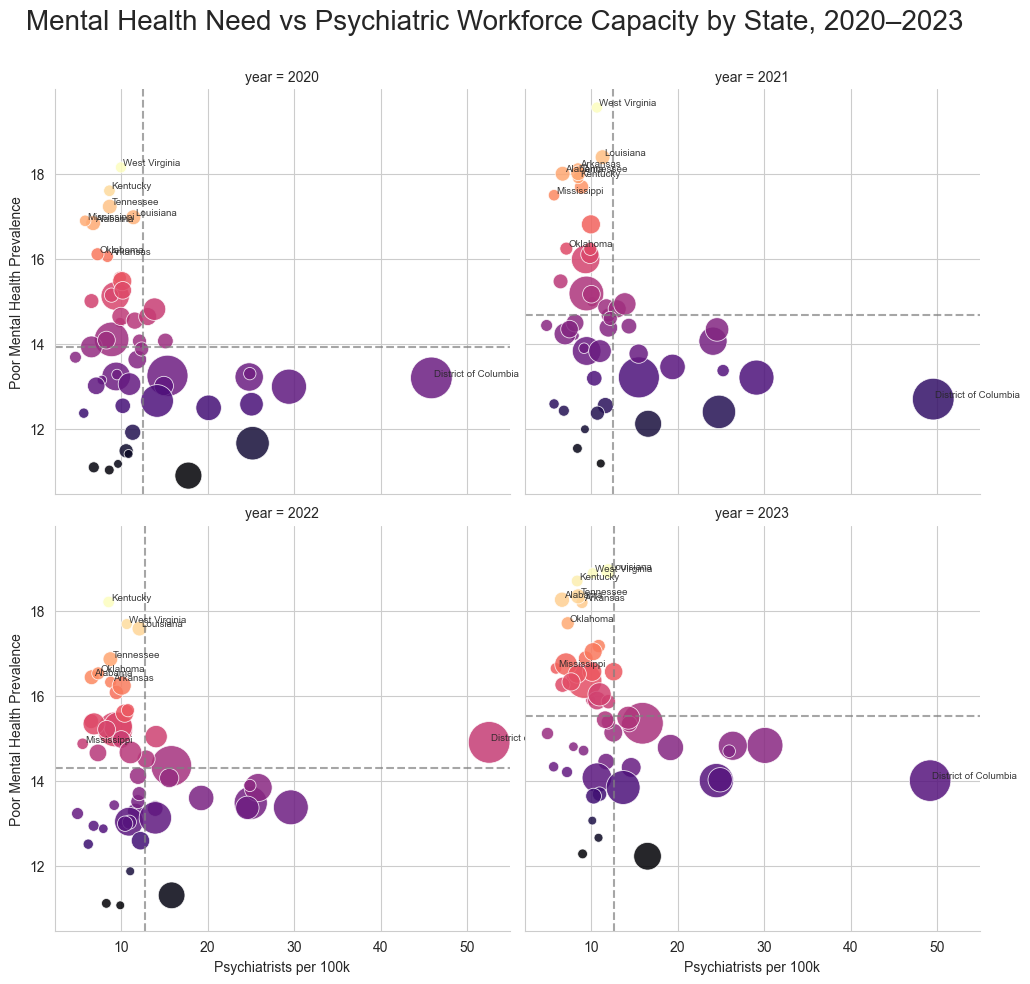

In [141]:
# ---------------------------------
# State-year analysis dataset
# ---------------------------------

state_year_analysis = (
    analysis_df.groupby(["state_full", "year"])
    .agg({
        "poor_mental_health": "mean",
        "psychiatrists_per_100k": "mean",
        "population": "mean"
    })
    .reset_index()
)

# Keep only years with valid psychiatrist data
state_year_analysis = state_year_analysis[
    state_year_analysis["year"].isin([2020, 2021, 2022, 2023])
]

state_year_analysis = state_year_analysis.dropna(
    subset=["psychiatrists_per_100k"]
)

# ---------------------------------
# Faceted longitudinal visualization
# ---------------------------------

sns.set_style("whitegrid")

g = sns.FacetGrid(
    state_year_analysis,
    col="year",
    col_wrap=2,
    height=5,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="psychiatrists_per_100k",
    y="poor_mental_health",
    size="population",
    hue="poor_mental_health",
    palette="magma",
    alpha=0.85,
    legend=False,
    sizes=(40, 900)
)

# ---------------------------------
# Add state labels + reference lines
# ---------------------------------

for ax, year in zip(
    g.axes.flat,
    sorted(state_year_analysis["year"].unique())
):

    year_df = state_year_analysis[
        state_year_analysis["year"] == year
    ]

    # National averages
    x_mean = year_df["psychiatrists_per_100k"].mean()
    y_mean = year_df["poor_mental_health"].mean()

    ax.axvline(
        x_mean,
        linestyle="--",
        color="gray",
        alpha=0.7
    )

    ax.axhline(
        y_mean,
        linestyle="--",
        color="gray",
        alpha=0.7
    )

    # ---------------------------------
    # Label selected states only
    # ---------------------------------

    important_states = [
        "West Virginia",
        "Kentucky",
        "Louisiana",
        "Tennessee",
        "Arkansas",
        "Mississippi",
        "Alabama",
        "Oklahoma",
        "District of Columbia"   # far-right outlier bubble
    ]

    label_df = year_df[
        year_df["state_full"].isin(important_states)
    ]

    for _, row in label_df.iterrows():

        # Extra spacing for California
        if row["state_full"] == "California":

            x_offset = 1.2
            y_offset = 0.15

        else:

            x_offset = 0.25
            y_offset = 0.05

        ax.text(
            row["psychiatrists_per_100k"] + x_offset,
            row["poor_mental_health"] + y_offset,
            row["state_full"],
            fontsize=7,
            alpha=0.9
        )

# ---------------------------------
# Titles and labels
# ---------------------------------

g.set_axis_labels(
    "Psychiatrists per 100k",
    "Poor Mental Health Prevalence"
)

g.fig.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Mental Health Need vs Psychiatric Workforce Capacity by State, 2020–2023",
    fontsize=20
)

plt.show()

In [142]:
# ---------------------------------
# Summary table:
# High-need, low-capacity states
# ---------------------------------

summary_table = (
    state_year_analysis
    .groupby("state_full")
    .agg({
        "poor_mental_health": "mean",
        "psychiatrists_per_100k": "mean",
        "population": "mean"
    })
    .reset_index()
)

# Construct simple state mismatch score
summary_table["state_mismatch_score"] = (
    summary_table["poor_mental_health"] /
    summary_table["psychiatrists_per_100k"]
)

summary_table = (
    summary_table
    .sort_values("state_mismatch_score", ascending=False)
)

summary_table = summary_table.rename(columns={
    "state_full": "State",
    "poor_mental_health": "Avg Poor Mental Health (%)",
    "psychiatrists_per_100k": "Psychiatrists per 100k",
    "population": "Average Population",
    "state_mismatch_score": "Need-Capacity Ratio"
})

summary_table.head(15)

,State,Avg Poor Mental Health (%),Psychiatrists per 100k,Average Population,Need-Capacity Ratio
12,Idaho,14.113636,4.8600,41301.755682,2.904040
24,Mississippi,16.476524,5.7475,36217.774390,2.866729
0,Alabama,17.384701,6.6600,73703.227612,2.610316
14,Indiana,15.533696,6.5525,73328.899457,2.370652
36,Oklahoma,16.645455,7.2500,51517.766234,2.295925
50,Wyoming,12.946739,5.8025,25191.597826,2.231235
28,Nevada,15.060294,6.8675,182305.852941,2.192981
17,Kentucky,18.104375,8.5125,37339.000000,2.126799
42,Tennessee,17.611579,8.6000,72266.410526,2.047858
3,Arkansas,17.172333,8.6425,40293.473333,1.986964


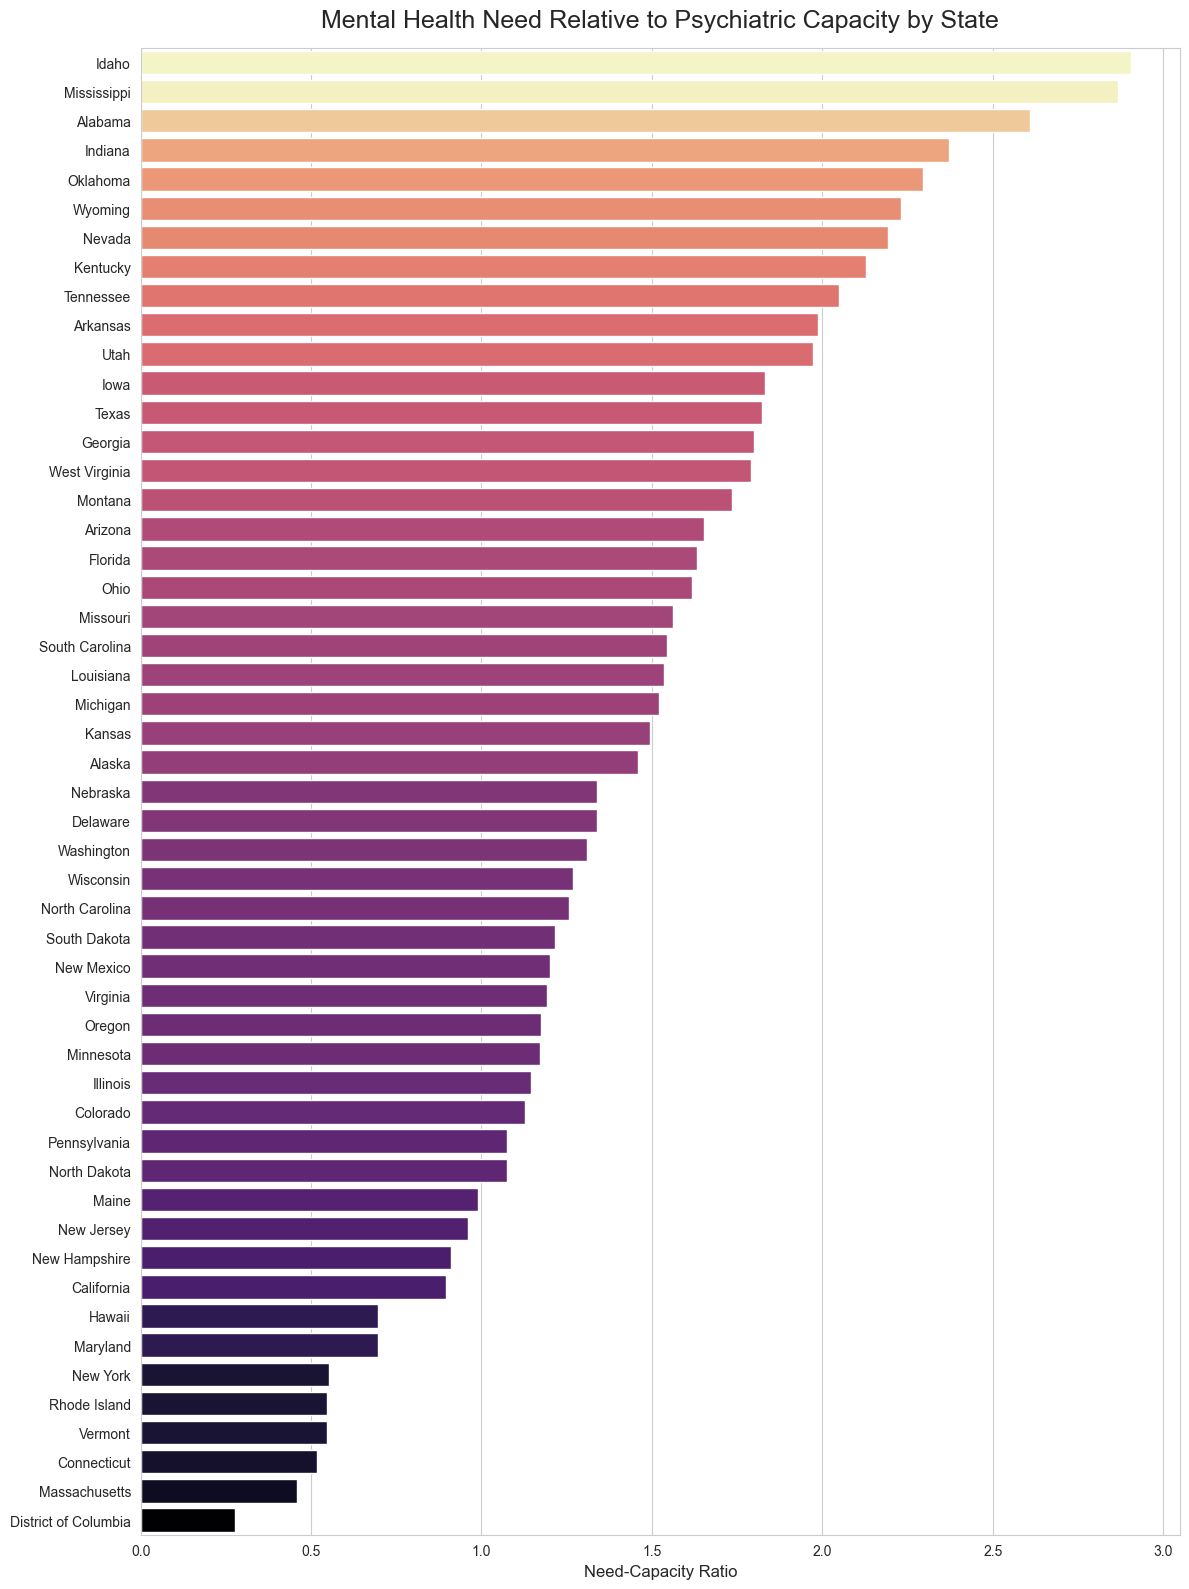

In [145]:
# ---------------------------------
# State need-capacity imbalance
# ---------------------------------

plot_df = summary_table.sort_values(
    "Need-Capacity Ratio",
    ascending=False
)

plt.figure(figsize=(12,16))

sns.barplot(
    data=plot_df,
    y="State",
    x="Need-Capacity Ratio",
    hue="Need-Capacity Ratio",
    palette="magma",
    dodge=False
)

plt.title(
    "Mental Health Need Relative to Psychiatric Capacity by State",
    fontsize=18,
    pad=15
)

plt.xlabel(
    "Need-Capacity Ratio",
    fontsize=12
)

plt.ylabel("")

plt.legend([], [], frameon=False)

plt.tight_layout()

plt.show()

This figure ranks states according to the ratio between estimated mental-health burden and psychiatrist workforce availability. Higher values indicate states where poor mental-health prevalence is high relative to available psychiatric workforce capacity. Several Southern and Appalachian states — including Idaho, Mississippi, Alabama, Oklahoma, Kentucky, and Tennessee — exhibit some of the highest imbalance levels in the country.

In contrast, states such as Massachusetts, Connecticut, New York, and the District of Columbia exhibit substantially lower imbalance ratios, reflecting comparatively greater psychiatrist availability relative to estimated mental-health burden. The visualization therefore highlights substantial geographic inequality in mental-health treatment capacity across the United States and reinforces the project’s broader argument that mental-health access should be understood relationally as the balance between need and healthcare infrastructure.

## Part 6 — Limitations

This project faces several important limitations related to geographic scale, measurement, and data availability. First, while CDC PLACES provides county-level estimates of mental-health burden, several infrastructure datasets, particularly AHRF psychiatrist workforce measures and SAMHSA facility data, are only consistently available at the state level in public-use form. As a result, some county-level analyses necessarily rely on broader state-level workforce estimates, which may obscure important local variation in treatment access.

Second, mental-health burden itself is likely substantially underreported. Many individuals experiencing mental-health challenges do not receive formal diagnoses or treatment because of stigma, cost barriers, lack of healthcare access, or under-detection within healthcare systems. The prevalence measures used in this project therefore likely underestimate the true scale of mental-health need in many communities.

Third, the analysis focuses specifically on psychiatrist workforce availability and inpatient psychiatric infrastructure. It does not include other important forms of mental-health support, including psychologists, licensed counselors, therapists, social workers, or community-based behavioral health services. As a result, the project should not be interpreted as a complete measure of all mental-health treatment capacity.

Finally, the mismatch index is a constructed measure rather than a direct observation of healthcare access. Although it combines mental-health burden, poverty, and psychiatrist availability in a theoretically meaningful way, alternative weighting strategies or additional variables could produce different estimates of mismatch. The analysis also remains descriptive rather than causal and therefore identifies geographic patterns of inequality without establishing direct causal relationships between infrastructure capacity and mental-health outcomes.


### Part 7

This project examined geographic inequality in mental-health burden relative to psychiatric workforce and treatment infrastructure across the United States between 2020 and 2025. By combining CDC PLACES, ACS, AHRF, and SAMHSA data, the analysis identified substantial variation in mental-health treatment capacity across states and counties. Several Southern and Appalachian states consistently exhibited high mental-health burden relative to psychiatrist availability, while states such as Massachusetts, Connecticut, and New York appeared comparatively better resourced.

Overall, the findings suggest that mental-health access should be understood relationally as the balance between population need and healthcare infrastructure rather than through raw provider counts alone. More broadly, the project demonstrates how combining multiple public administrative datasets can help identify regions where mental-health treatment capacity may not adequately match community need.

References
1. CDC PLACES Data: Local Data for Better Health — https://www.cdc.gov/places/
2. American Community Survey (ACS) 5-Year Estimates — https://www.census.gov/programs-surveys/acs
3. Area Health Resources Files (AHRF) — https://data.hrsa.gov/topics/health-workforce/ahrf
4. SAMHSA National Mental Health Services Survey (N-MHSS) — https://www.samhsa.gov/data/data-we-collect/nmhss-national-mental-health-services-survey
5. Thomas, K. C., Ellis, A. R., Konrad, T. R., Holzer, C. E., & Morrissey, J. P. (2009). County-level estimates of mental health professional shortage in the United States. 
6. Psychiatric Services, 60(10), 1323–1328. https://psychiatryonline.org/doi/10.1176/ps.2009.60.10.1323
7. Association of American Medical Colleges (AAMC). Exploring Barriers to Mental Health Care in the U.S. — https://www.aamc.org/about-us/mission-areas/clinical-care/exploring-barriers-mental-health-care-us